In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from google.cloud import bigquery

PROJECT_ID = "nyc-taxi-analytics-1"

client = bigquery.Client(project=PROJECT_ID)

def run_query(query: str) -> pd.DataFrame:
    query_job = client.query(query)
    return query_job.result().to_dataframe()

In [3]:
query_monthly_revenue = f"""
SELECT
    pickup_year_month,
    total_trips,
    gross_trip_amount,
    core_fare_amount,
    total_tip_amount,
    avg_gross_trip_amount,
    tip_rate_percentage,
    gross_trip_amount_mom_growth_percentage,
    component_reconciliation_difference
FROM `{PROJECT_ID}.nyc_taxi_dbt_reporting.rpt_monthly_revenue_performance`
ORDER BY pickup_year_month
"""

df_monthly_revenue = run_query(query_monthly_revenue)
df_monthly_revenue

,pickup_year_month,total_trips,gross_trip_amount,core_fare_amount,total_tip_amount,avg_gross_trip_amount,tip_rate_percentage,gross_trip_amount_mom_growth_percentage,component_reconciliation_difference
0,2023-01,2868243,78298334.10,52954592.91,9790104.67,27.30,18.49,NaN,-1780621.80
1,2023-02,2717287,74005116.26,49880864.33,9352528.93,27.23,18.75,-5.48,-1709621.70
2,2023-03,3169021,89231212.21,60338247.39,11281879.71,28.16,18.70,20.57,-2036109.85
3,2023-04,3057587,87552922.91,59622474.28,10938957.45,28.63,18.35,-1.88,-1935523.30
4,2023-05,3260640,95591416.52,65219277.42,11988480.08,29.32,18.38,9.18,-2025448.45
5,2023-06,3066303,90215417.74,61658588.51,11226278.82,29.42,18.21,-5.62,-1902923.90
6,2023-07,2694638,78193062.41,53612332.76,9494790.91,29.02,17.71,-13.33,-1595239.70
7,2023-08,2606299,75900018.16,51891241.98,9155639.42,29.12,17.64,-2.93,-1507719.25
8,2023-09,2584900,78221959.33,53746592.53,9744027.83,30.26,18.13,3.06,-1445856.35
9,2023-10,3218306,95540264.16,65076038.88,12145903.01,29.69,18.66,22.14,-1800382.80


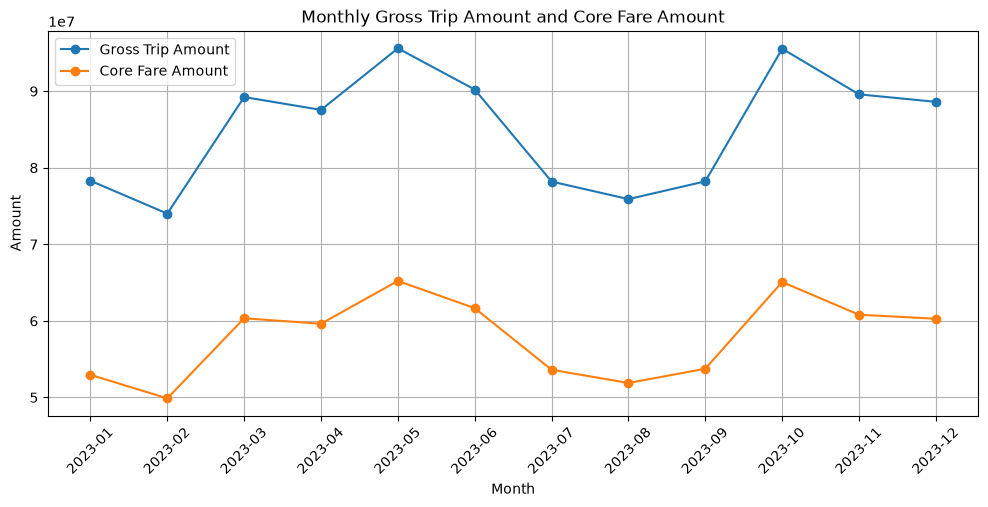

In [4]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_monthly_revenue["pickup_year_month"],
    df_monthly_revenue["gross_trip_amount"],
    marker="o",
    label="Gross Trip Amount"
)

plt.plot(
    df_monthly_revenue["pickup_year_month"],
    df_monthly_revenue["core_fare_amount"],
    marker="o",
    label="Core Fare Amount"
)

plt.title("Monthly Gross Trip Amount and Core Fare Amount")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

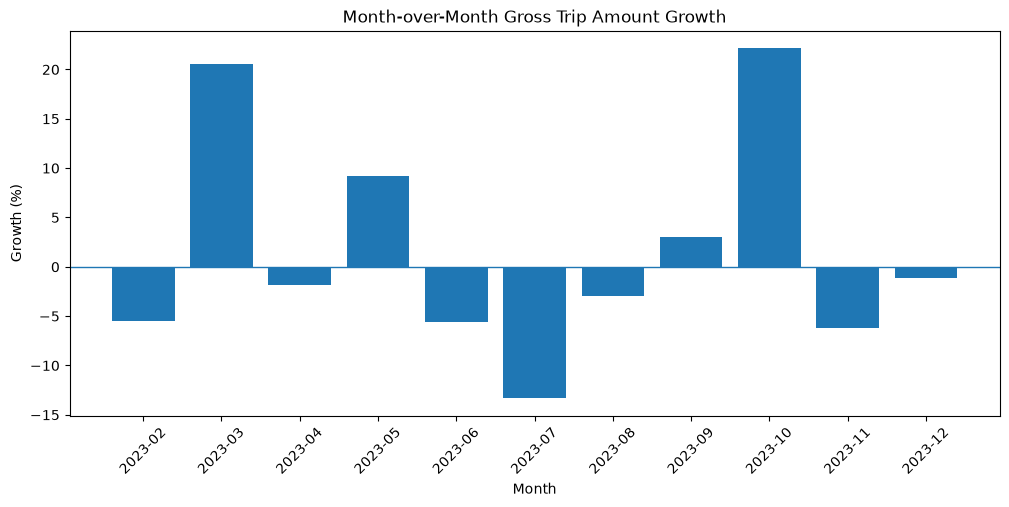

In [5]:
plt.figure(figsize=(12, 5))

plt.bar(
    df_monthly_revenue["pickup_year_month"],
    df_monthly_revenue["gross_trip_amount_mom_growth_percentage"]
)

plt.title("Month-over-Month Gross Trip Amount Growth")
plt.xlabel("Month")
plt.ylabel("Growth (%)")
plt.xticks(rotation=45)
plt.axhline(0, linewidth=1)
plt.show()

In [6]:
query_components = f"""
SELECT
    component_name,
    component_group,
    component_amount,
    gross_trip_amount_share_percentage,
    contribution_rank
FROM `{PROJECT_ID}.nyc_taxi_dbt_reporting.rpt_revenue_component_contribution`
ORDER BY component_amount DESC
"""

df_components = run_query(query_components)
df_components

,component_name,component_group,component_amount,gross_trip_amount_share_percentage,contribution_rank
0,Core Fare,Fare,6.950799e+08,68.08,1
1,Tip,Gratuity,1.278695e+08,12.52,2
2,Congestion Surcharge,Tax and Surcharge,8.261387e+07,8.09,3
3,Extra,Tax and Surcharge,5.739580e+07,5.62,4
4,Improvement Surcharge,Tax and Surcharge,3.534893e+07,3.46,5
5,Tolls,Tolls,2.113869e+07,2.07,6
6,MTA Tax,Tax and Surcharge,1.757306e+07,1.72,7
7,Airport Fee,Tax and Surcharge,5.128408e+06,0.50,8


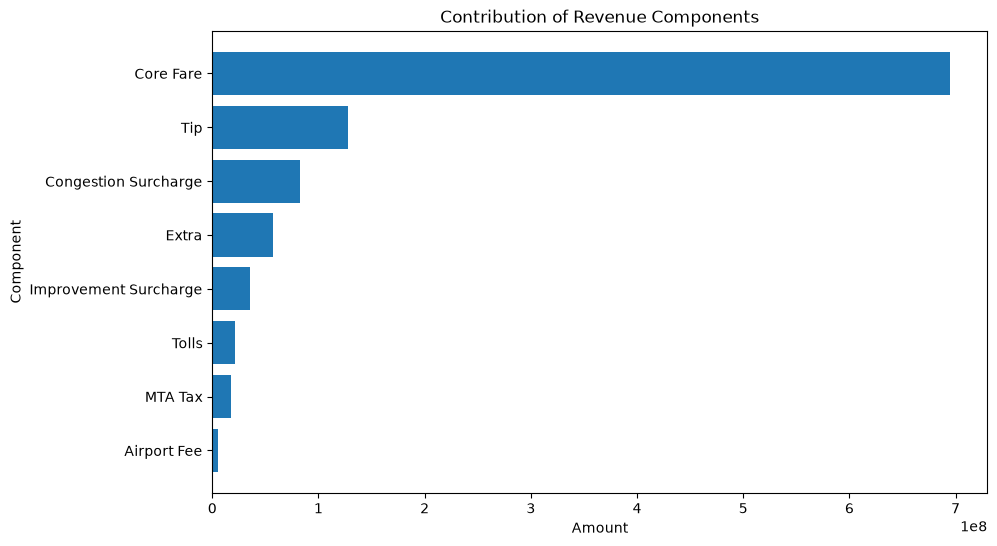

In [7]:
component_chart = df_components.sort_values(
    "component_amount",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    component_chart["component_name"],
    component_chart["component_amount"]
)

plt.title("Contribution of Revenue Components")
plt.xlabel("Amount")
plt.ylabel("Component")
plt.show()

In [8]:
query_time_period = f"""
SELECT
    pickup_time_period,
    time_period_order,
    total_trips,
    gross_trip_amount,
    core_fare_amount,
    total_tip_amount,
    avg_gross_trip_amount,
    tip_rate_percentage,
    gross_trip_amount_rank
FROM `{PROJECT_ID}.nyc_taxi_dbt_reporting.rpt_revenue_time_period`
ORDER BY time_period_order
"""

df_time_revenue = run_query(query_time_period)
df_time_revenue

,pickup_time_period,time_period_order,total_trips,gross_trip_amount,core_fare_amount,total_tip_amount,avg_gross_trip_amount,tip_rate_percentage,gross_trip_amount_rank
0,Late night,1,2739411,7.844353e+07,5.381930e+07,9483913.61,28.64,17.62,5
1,Morning,2,5836073,1.603687e+08,1.116450e+08,20025785.37,27.48,17.94,3
2,Midday,3,10067847,2.908614e+08,2.045210e+08,36040097.44,28.89,17.62,2
3,Evening,4,11390492,3.350481e+08,2.191860e+08,42240246.37,29.41,19.27,1
4,Night,5,5325484,1.562145e+08,1.059085e+08,20079430.70,29.33,18.96,4


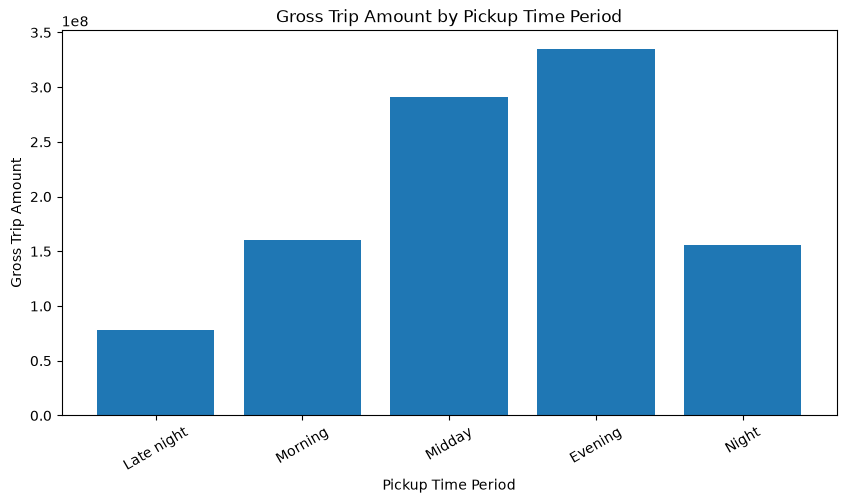

In [9]:
plt.figure(figsize=(10, 5))

plt.bar(
    df_time_revenue["pickup_time_period"],
    df_time_revenue["gross_trip_amount"]
)

plt.title("Gross Trip Amount by Pickup Time Period")
plt.xlabel("Pickup Time Period")
plt.ylabel("Gross Trip Amount")
plt.xticks(rotation=30)
plt.show()

In [10]:
query_top_revenue_zones = f"""
SELECT
    pickup_borough,
    pickup_zone,
    total_trips,
    total_revenue,
    avg_revenue_per_trip,
    avg_trip_distance,
    revenue_rank
FROM `{PROJECT_ID}.nyc_taxi_dbt_reporting.rpt_pickup_location_performance`
ORDER BY total_revenue DESC
LIMIT 20
"""

df_top_revenue_zones = run_query(query_top_revenue_zones)

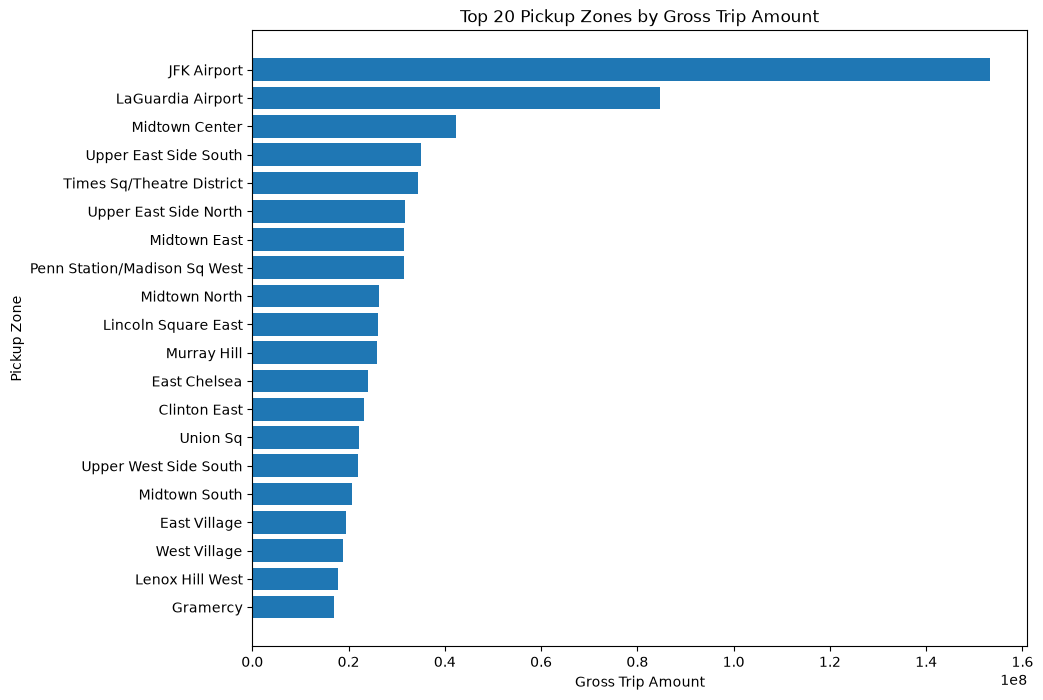

In [11]:
zone_chart = df_top_revenue_zones.sort_values(
    "total_revenue",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    zone_chart["pickup_zone"],
    zone_chart["total_revenue"]
)

plt.title("Top 20 Pickup Zones by Gross Trip Amount")
plt.xlabel("Gross Trip Amount")
plt.ylabel("Pickup Zone")
plt.show()

In [12]:
query_outlier_impact = f"""
SELECT
    revenue_group,
    upper_total_amount_threshold,
    total_trips,
    trip_share_percentage,
    gross_trip_amount,
    gross_trip_amount_share_percentage,
    avg_gross_trip_amount,
    avg_trip_distance,
    avg_trip_duration_minutes
FROM `{PROJECT_ID}.nyc_taxi_dbt_reporting.rpt_revenue_outlier_impact`
ORDER BY revenue_group_order
"""

df_revenue_outlier = run_query(query_outlier_impact)
df_revenue_outlier

,revenue_group,upper_total_amount_threshold,total_trips,trip_share_percentage,gross_trip_amount,gross_trip_amount_share_percentage,avg_gross_trip_amount,avg_trip_distance,avg_trip_duration_minutes
0,Non-revenue-outlier,52.56,31225647,88.31,6.798151e+08,66.59,21.77,2.15,14.16
1,Revenue outlier,52.56,4133660,11.69,3.411211e+08,33.41,82.52,14.33,42.46


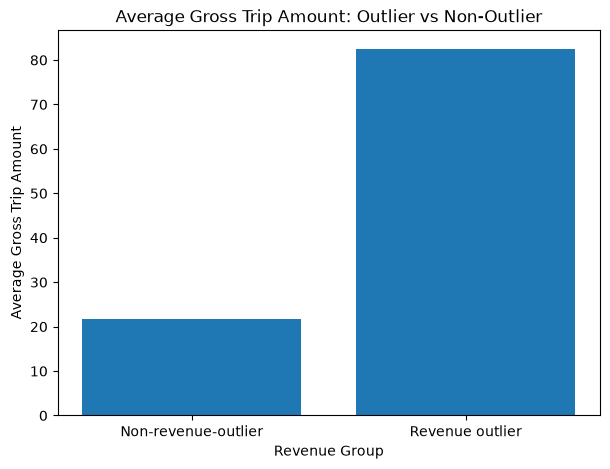

In [13]:
plt.figure(figsize=(7, 5))

plt.bar(
    df_revenue_outlier["revenue_group"],
    df_revenue_outlier["avg_gross_trip_amount"]
)

plt.title("Average Gross Trip Amount: Outlier vs Non-Outlier")
plt.xlabel("Revenue Group")
plt.ylabel("Average Gross Trip Amount")
plt.show()